In [153]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [154]:
PROJECT_ROOT = Path("..")

DATA_FILE = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"
RESULTS_DIR = PROJECT_ROOT / "results" / "qc"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(DATA_FILE)
print(DATA_FILE.exists())

../data/processed/final_dataset.csv
True


In [155]:
ancova = pd.read_csv(
    "../results/ancova/repeated_measures_ancova_all_effects.csv"
)

In [156]:
df.columns.tolist()

['filename',
 'central_recording_min',
 'frontal_recording_min',
 'occipital_recording_min',
 'parietal_recording_min',
 'central_sleep_period_min',
 'frontal_sleep_period_min',
 'occipital_sleep_period_min',
 'parietal_sleep_period_min',
 'central_total_N2_valid_min',
 'frontal_total_N2_valid_min',
 'occipital_total_N2_valid_min',
 'parietal_total_N2_valid_min',
 'central_total_N3_valid_min',
 'frontal_total_N3_valid_min',
 'occipital_total_N3_valid_min',
 'parietal_total_N3_valid_min',
 'central_total_valid_min',
 'frontal_total_valid_min',
 'occipital_total_valid_min',
 'parietal_total_valid_min',
 'central_total_N2_sw_count',
 'frontal_total_N2_sw_count',
 'occipital_total_N2_sw_count',
 'parietal_total_N2_sw_count',
 'central_total_N3_sw_count',
 'frontal_total_N3_sw_count',
 'occipital_total_N3_sw_count',
 'parietal_total_N3_sw_count',
 'central_total_sw_count',
 'frontal_total_sw_count',
 'occipital_total_sw_count',
 'parietal_total_sw_count',
 'central_total_N2_sw_sec',
 'front

In [157]:
df = pd.read_csv(DATA_FILE)

print(df.shape)
df.head()

(97, 116)


,filename,central_recording_min,frontal_recording_min,occipital_recording_min,parietal_recording_min,central_sleep_period_min,frontal_sleep_period_min,occipital_sleep_period_min,parietal_sleep_period_min,central_total_N2_valid_min,...,Âge à la PSG,UPDRS-I-2 Hallucinations,UPDRS-I Total,UPDRS-III Total -0.5,Durée de suivi,conversion_clean,Group,converter,conversion_status,conversion_subtype
0,R108_2010,487.999884,487.999884,487.999884,487.999884,463.499881,463.499881,463.499881,463.499881,331.880021,...,75.0,1.0,2.0,4.0,0.0,oui,Converti,1,Converter,DLB
1,R122_2010,500.999979,500.999979,500.999979,500.999979,459.499975,459.499975,459.499975,459.499975,213.806309,...,65.0,0.0,0.0,4.0,4.0,NaN,Non-converti,0,Non-converter,Non-converter
2,R12_2005,478.000007,478.000007,478.000007,478.000007,475.000006,475.000006,475.000006,475.000006,118.981279,...,63.0,1.0,1.0,2.0,3.0,oui,Converti,1,Converter,PD-MCI
3,R15_2004,509.999998,509.999998,509.999998,509.999998,500.499996,500.499996,500.499996,500.499996,221.466607,...,69.0,0.0,1.0,3.0,8.0,oui,Converti,1,Converter,PD
4,R165_2014,473.999968,473.999968,473.999968,473.999968,468.999963,468.999963,468.999963,468.999963,255.729338,...,68.0,0.0,0.0,1.0,9.0,NaN,Non-converti,0,Non-converter,Non-converter


In [158]:
df["filename"].duplicated().sum()

np.int64(0)

In [159]:
df["filename"].nunique()

97

In [160]:
#on va vérifier ma variable cible relative au statut de conversion
df["converter"].value_counts(dropna=False)

converter
0    60
1    37
Name: count, dtype: int64

In [161]:
df["conversion_status"].value_counts(dropna=False)

conversion_status
Non-converter    60
Converter        37
Name: count, dtype: int64

In [162]:
#On vérifie aussi le sous type de maladie parmi les covertisseurs 
df["conversion_subtype"].value_counts(dropna=False)

conversion_subtype
Non-converter    60
DLB              20
PD                9
PD-MCI            8
Name: count, dtype: int64

In [163]:

#on vérifie les variables manquante : 
missing = df.isna().sum().sort_values(ascending=False)

missing.head(30)

Sous-type (2=PD cognition normale, 3=PD-MCI, 4=DLB, 5=MSA, 6=PDD)    60
conversion_clean                                                     60
Conversion                                                           60
occipital_total_N3_slope_0_min                                       33
occipital_total_N3_pkpk_amp_uV                                       33
occipital_total_N3_trans_freq_Hz                                     33
occipital_total_N3_freq_Hz                                           33
occipital_total_N3_sw_sec                                            33
parietal_total_N3_trans_freq_Hz                                      20
parietal_total_N3_freq_Hz                                            20
parietal_total_N3_sw_sec                                             20
parietal_total_N3_slope_0_min                                        20
parietal_total_N3_pkpk_amp_uV                                        20
central_total_N3_pkpk_amp_uV                                    

In [164]:
#On sauvegarde les missing values
missing.to_csv(RESULTS_DIR / "missing_values.csv")

In [165]:
# on vérifie les colonnes qui contiennennt beaucoup de valeurs manquantes 
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_percent.head(30)


Sous-type (2=PD cognition normale, 3=PD-MCI, 4=DLB, 5=MSA, 6=PDD)    61.855670
conversion_clean                                                     61.855670
Conversion                                                           61.855670
occipital_total_N3_slope_0_min                                       34.020619
occipital_total_N3_pkpk_amp_uV                                       34.020619
occipital_total_N3_trans_freq_Hz                                     34.020619
occipital_total_N3_freq_Hz                                           34.020619
occipital_total_N3_sw_sec                                            34.020619
parietal_total_N3_trans_freq_Hz                                      20.618557
parietal_total_N3_freq_Hz                                            20.618557
parietal_total_N3_sw_sec                                             20.618557
parietal_total_N3_slope_0_min                                        20.618557
parietal_total_N3_pkpk_amp_uV                       

In [166]:
#On vérifie ensuite le pourcentage de varaibles manquantes et on l'intègre dans le dossier des valeurs manqutes 
missing_percent.to_csv(RESULTS_DIR / "missing_values_percent.csv")

In [167]:
# on identifie les variables numériques
numeric_cols = df.select_dtypes(include="number").columns.tolist()

numeric_cols

['central_recording_min',
 'frontal_recording_min',
 'occipital_recording_min',
 'parietal_recording_min',
 'central_sleep_period_min',
 'frontal_sleep_period_min',
 'occipital_sleep_period_min',
 'parietal_sleep_period_min',
 'central_total_N2_valid_min',
 'frontal_total_N2_valid_min',
 'occipital_total_N2_valid_min',
 'parietal_total_N2_valid_min',
 'central_total_N3_valid_min',
 'frontal_total_N3_valid_min',
 'occipital_total_N3_valid_min',
 'parietal_total_N3_valid_min',
 'central_total_valid_min',
 'frontal_total_valid_min',
 'occipital_total_valid_min',
 'parietal_total_valid_min',
 'central_total_N2_sw_count',
 'frontal_total_N2_sw_count',
 'occipital_total_N2_sw_count',
 'parietal_total_N2_sw_count',
 'central_total_N3_sw_count',
 'frontal_total_N3_sw_count',
 'occipital_total_N3_sw_count',
 'parietal_total_N3_sw_count',
 'central_total_sw_count',
 'frontal_total_sw_count',
 'occipital_total_sw_count',
 'parietal_total_sw_count',
 'central_total_N2_sw_sec',
 'frontal_total_N2_s

In [168]:
#on enlève maintenant les variables qui ne sont pas des variables prédictrices 
exclude_cols = [
    "converter"
]

feature_cols = [
    col for col in numeric_cols
    if col not in exclude_cols
]

len(feature_cols)

106

In [169]:
#on vérifie qu'on est au bon endroit
from pathlib import Path
print(Path.cwd())

/Users/asus/RBD_SW_sleep_conversion/RBD_SW_sleep_conversion/notebooks


In [170]:
# on vérifie les colonnes
print(df.columns.tolist())

['filename', 'central_recording_min', 'frontal_recording_min', 'occipital_recording_min', 'parietal_recording_min', 'central_sleep_period_min', 'frontal_sleep_period_min', 'occipital_sleep_period_min', 'parietal_sleep_period_min', 'central_total_N2_valid_min', 'frontal_total_N2_valid_min', 'occipital_total_N2_valid_min', 'parietal_total_N2_valid_min', 'central_total_N3_valid_min', 'frontal_total_N3_valid_min', 'occipital_total_N3_valid_min', 'parietal_total_N3_valid_min', 'central_total_valid_min', 'frontal_total_valid_min', 'occipital_total_valid_min', 'parietal_total_valid_min', 'central_total_N2_sw_count', 'frontal_total_N2_sw_count', 'occipital_total_N2_sw_count', 'parietal_total_N2_sw_count', 'central_total_N3_sw_count', 'frontal_total_N3_sw_count', 'occipital_total_N3_sw_count', 'parietal_total_N3_sw_count', 'central_total_sw_count', 'frontal_total_sw_count', 'occipital_total_sw_count', 'parietal_total_sw_count', 'central_total_N2_sw_sec', 'frontal_total_N2_sw_sec', 'occipital_to

In [171]:
#on vérifie les valeurs manquantes 
missing = df.isna().sum()

missing.sort_values(
    ascending=False
).head(20)

Sous-type (2=PD cognition normale, 3=PD-MCI, 4=DLB, 5=MSA, 6=PDD)    60
conversion_clean                                                     60
Conversion                                                           60
occipital_total_N3_slope_0_min                                       33
occipital_total_N3_pkpk_amp_uV                                       33
occipital_total_N3_trans_freq_Hz                                     33
occipital_total_N3_freq_Hz                                           33
occipital_total_N3_sw_sec                                            33
parietal_total_N3_trans_freq_Hz                                      20
parietal_total_N3_freq_Hz                                            20
parietal_total_N3_sw_sec                                             20
parietal_total_N3_slope_0_min                                        20
parietal_total_N3_pkpk_amp_uV                                        20
central_total_N3_pkpk_amp_uV                                    

In [172]:
# on vérifie les stats globales peu importe le groupe
summary = df[feature_cols].describe().T

summary.head()

,count,mean,std,min,25%,50%,75%,max
central_recording_min,97.0,491.902028,31.983041,429.500007,478.999941,483.999977,503.500000,640.999938
frontal_recording_min,97.0,491.902028,31.983041,429.500007,478.999941,483.999977,503.500000,640.999938
occipital_recording_min,92.0,492.978228,31.517124,429.500007,479.374978,484.499965,503.500005,640.999938
parietal_recording_min,97.0,491.902028,31.983041,429.500007,478.999941,483.999977,503.500000,640.999938
central_sleep_period_min,97.0,460.742230,36.167226,323.999963,439.999963,460.999954,476.499983,603.999968


In [173]:
#On sauvegarde
summary.to_csv(RESULTS_DIR / "summary_statistics.csv")

In [174]:
#on vérifie les valeurs impossible (comme une densiténégative)
mins = df[feature_cols].min().sort_values()

mins.head(20)

Durée de suivi                      0.000000
occipital_total_sw_count            0.000000
parietal_total_N3_sw_count          0.000000
occipital_total_N3_sw_count         0.000000
frontal_total_N3_sw_count           0.000000
occipital_total_N2_sw_count         0.000000
parietal_total_N3_valid_min         0.000000
occipital_total_N3_valid_min        0.000000
frontal_total_N3_valid_min          0.000000
central_total_N3_valid_min          0.000000
central_total_N3_sw_count           0.000000
UPDRS-I Total                       0.000000
UPDRS-I-2 Hallucinations            0.000000
occipital_density_sw                0.000000
UPDRS-III Total -0.5                0.000000
central_density_sw                  0.021991
parietal_density_sw                 0.026579
frontal_density_sw                  0.031796
occipital_total_N2_trans_freq_Hz    0.390000
occipital_total_trans_freq_Hz       0.390000
dtype: float64

In [175]:
maxs = df[feature_cols].max().sort_values(ascending=False)

maxs.head(20)

frontal_total_sw_count           4794.000000
central_total_sw_count           4084.000000
parietal_total_sw_count          3581.000000
frontal_total_N3_sw_count        3265.000000
central_total_N3_sw_count        2760.000000
parietal_total_N3_sw_count       2324.000000
frontal_total_N2_sw_count        2157.500000
central_total_N2_sw_count        1462.000000
parietal_total_N2_sw_count       1256.000000
occipital_total_sw_count         1216.000000
occipital_total_N3_sw_count       981.000000
central_recording_min             640.999938
parietal_recording_min            640.999938
occipital_recording_min           640.999938
frontal_recording_min             640.999938
parietal_sleep_period_min         603.999968
occipital_sleep_period_min        603.999968
frontal_sleep_period_min          603.999968
central_sleep_period_min          603.999968
parietal_total_N2_slope_0_min     512.480000
dtype: float64

In [176]:
#On vérifie qu'on a créée les bonnes régions si elle poss;dent le meme nombre de varaibles  
region_prefixes = ["frontal", "central", "parietal", "occipital"]

for region in region_prefixes:
    cols = [col for col in df.columns if col.startswith(region + "_")]
    print(region, len(cols))

frontal 25
central 25
parietal 25
occipital 25


In [177]:
#On véridie les variables de densité par région
density_cols = [
    col for col in df.columns
    if "density" in col.lower()
]

density_cols

['central_density_sw',
 'frontal_density_sw',
 'occipital_density_sw',
 'parietal_density_sw']

In [178]:
df[density_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
central_density_sw,97.0,2.317285,2.524425,0.021991,0.641643,1.638591,2.685618,13.608748
frontal_density_sw,97.0,3.943880,3.736779,0.031796,1.437834,2.924989,5.126437,21.274647
occipital_density_sw,92.0,0.545302,0.867794,0.000000,0.029415,0.222417,0.700276,5.654743
parietal_density_sw,97.0,1.747209,2.033333,0.026579,0.375207,1.090797,2.405002,11.879176


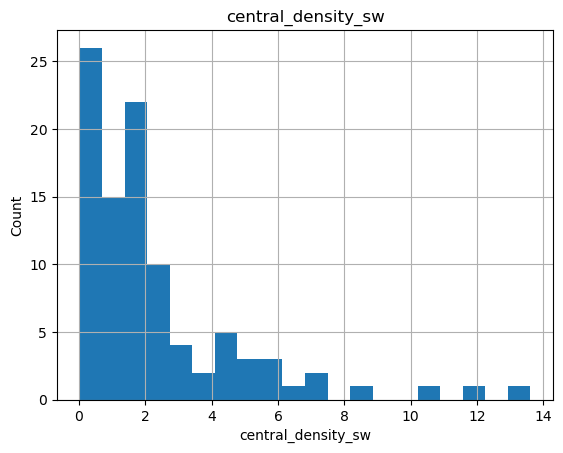

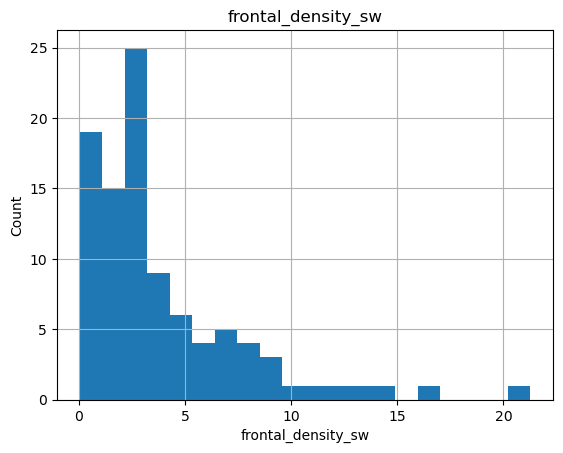

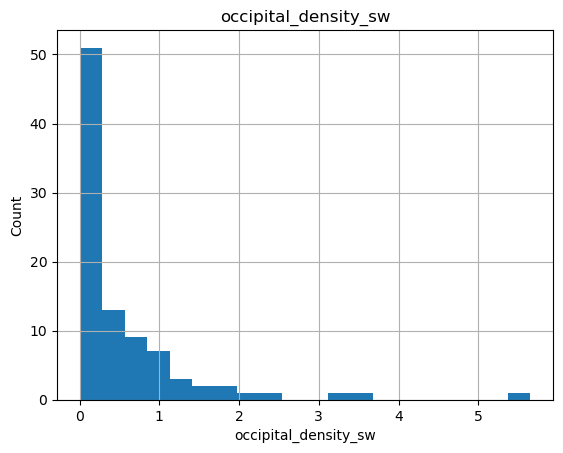

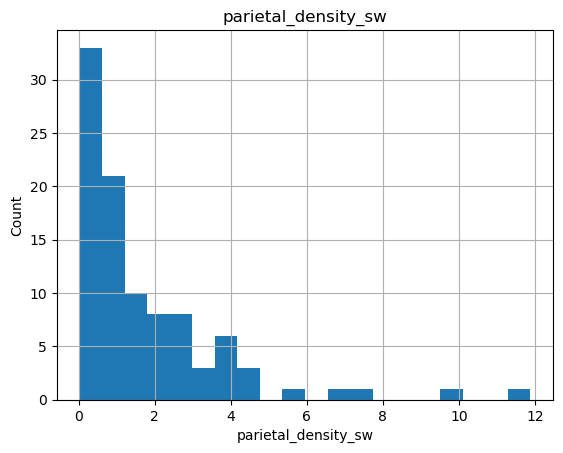

In [179]:
#on visualise la densité par région
import matplotlib.pyplot as plt
for col in density_cols:
    plt.figure()
    df[col].hist(bins=20)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [180]:
#On compare les convertisseurs et les non convertisseur
df.groupby("conversion_status")[density_cols].mean()

,central_density_sw,frontal_density_sw,occipital_density_sw,parietal_density_sw
conversion_status,,,,
Converter,2.741674,4.319353,0.888524,2.292619
Non-converter,2.055578,3.712338,0.344102,1.410873


In [181]:
df.groupby("conversion_status")[density_cols].std()

,central_density_sw,frontal_density_sw,occipital_density_sw,parietal_density_sw
conversion_status,,,,
Converter,2.976055,3.874174,1.210608,2.612166
Non-converter,2.186862,3.663222,0.492256,1.504063


<Figure size 640x480 with 0 Axes>

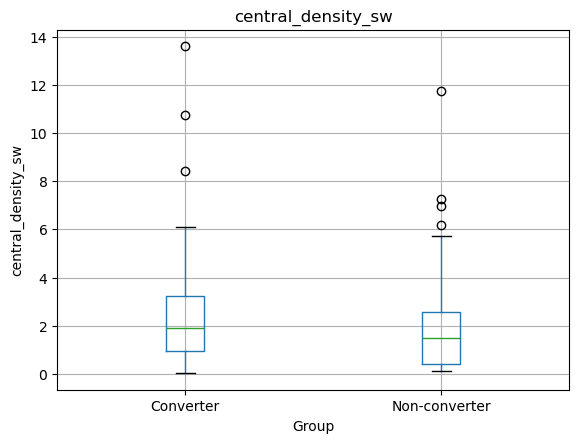

<Figure size 640x480 with 0 Axes>

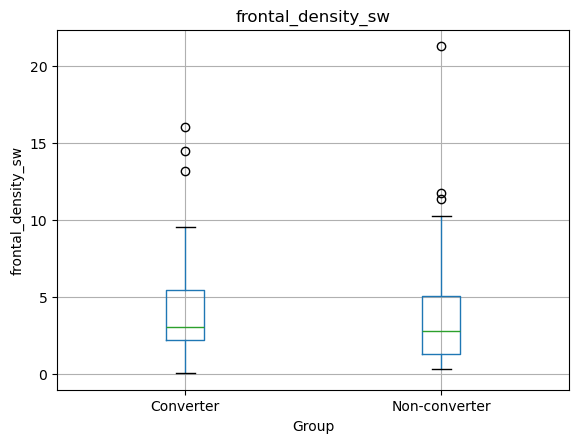

<Figure size 640x480 with 0 Axes>

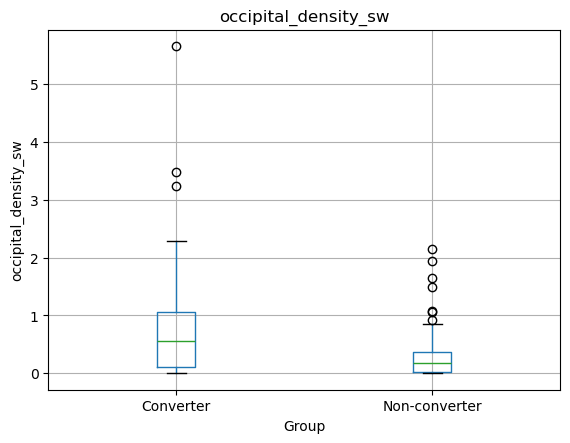

<Figure size 640x480 with 0 Axes>

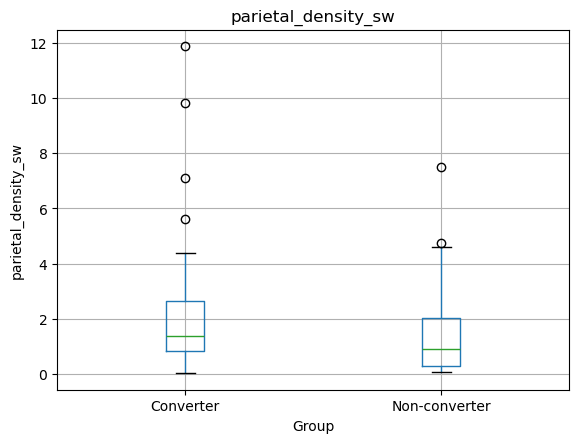

In [182]:
# on plot les deux groupes pour chaque région 
for col in density_cols:
    plt.figure()
    df.boxplot(column=col, by="conversion_status")
    plt.title(col)
    plt.suptitle("")
    plt.xlabel("Group")
    plt.ylabel(col)
    plt.show()

In [183]:
#On vérifie les variables n2 et N3 
n2_cols = [
    col for col in df.columns
    if "N2" in col
]

n3_cols = [
    col for col in df.columns
    if "N3" in col
]

print("N2 variables:", len(n2_cols))
print("N3 variables:", len(n3_cols))
n2_cols[:10], n3_cols[:10]


N2 variables: 28
N3 variables: 28


(['central_total_N2_valid_min',
  'frontal_total_N2_valid_min',
  'occipital_total_N2_valid_min',
  'parietal_total_N2_valid_min',
  'central_total_N2_sw_count',
  'frontal_total_N2_sw_count',
  'occipital_total_N2_sw_count',
  'parietal_total_N2_sw_count',
  'central_total_N2_sw_sec',
  'frontal_total_N2_sw_sec'],
 ['central_total_N3_valid_min',
  'frontal_total_N3_valid_min',
  'occipital_total_N3_valid_min',
  'parietal_total_N3_valid_min',
  'central_total_N3_sw_count',
  'frontal_total_N3_sw_count',
  'occipital_total_N3_sw_count',
  'parietal_total_N3_sw_count',
  'central_total_N3_sw_sec',
  'frontal_total_N3_sw_sec'])

In [184]:
#on réalise une matrice de correlation simple : 
corr_cols = density_cols + [
    col for col in df.columns
    if "trans_freq" in col
]

corr = df[corr_cols].corr()

corr
corr.to_csv(RESULTS_DIR / "correlation_matrix.csv")


In [185]:
# On réalise un résum automatique du quality check
qc_summary = {
    "n_rows": df.shape[0],
    "n_columns": df.shape[1],
    "n_unique_filenames": df["filename"].nunique(),
    "duplicated_filenames": df["filename"].duplicated().sum(),
    "n_converters": int((df["converter"] == 1).sum()),
    "n_non_converters": int((df["converter"] == 0).sum()),
    "n_numeric_features": len(feature_cols),
}

qc_summary
pd.Series(qc_summary).to_csv(RESULTS_DIR / "qc_summary.csv")

In [186]:
#on documente 
## Quality control of final dataset

#After creating the participant-level regional dataset, quality control was performed to verify:

#- one row per filename/participant;
#- presence of the four EEG regions: frontal, central, parietal, occipital;
#- correct binary conversion variable;
#- correct disease subtype labels;
#- missing values per variable;
#- descriptive statistics;
#- distributions of key slow-wave variables;
#- correlations between regional slow-wave predictors.

#The QC outputs are stored in `results/qc/`.

In [187]:
#VISUALISATION DES RÉSULTATS DE L'ANCOVA 
ancova = pd.read_csv(
    "../results/ancova/repeated_measures_ancova_all_effects.csv"
)

ancova.head()


,effect,sum_sq,df,F,PR(>F),variable
0,C(conversion_status),1.092981,1.0,0.510955,4.753673e-01,density_sw
1,C(region),535.859315,3.0,83.502460,7.312536e-38,density_sw
2,C(filename),2221.215980,89.0,11.667304,1.972388e-54,density_sw
3,C(conversion_status):C(region),2.018037,3.0,0.314469,8.149179e-01,density_sw
4,"Q(""UPDRS-I Total"")",0.530883,1.0,0.248181,6.187800e-01,density_sw


In [188]:
# on regarde uniquement les effets principaux 
effects_of_interest = ancova[
    ancova["effect"].isin([
        "C(conversion_status)",
        "C(region)",
        "C(conversion_status):C(region)"
    ])
]

effects_of_interest

,effect,sum_sq,df,F,PR(>F),variable
0,C(conversion_status),1.092981e+00,1.0,0.510955,4.753673e-01,density_sw
1,C(region),5.358593e+02,3.0,83.502460,7.312536e-38,density_sw
3,C(conversion_status):C(region),2.018037e+00,3.0,0.314469,8.149179e-01,density_sw
7,C(conversion_status),3.068831e+04,1.0,0.981298,3.227997e-01,total_N2_sw_count
8,C(region),1.069147e+07,3.0,113.957809,3.980841e-47,total_N2_sw_count
10,C(conversion_status):C(region),9.598006e+04,3.0,1.023028,3.829257e-01,total_N2_sw_count
14,C(conversion_status),4.007926e+05,1.0,8.714675,3.445014e-03,total_N3_sw_count
15,C(region),3.460447e+06,3.0,25.080863,2.764961e-14,total_N3_sw_count
17,C(conversion_status):C(region),3.377887e+05,3.0,2.448248,6.414816e-02,total_N3_sw_count
21,C(conversion_status),6.537497e+05,1.0,5.905269,1.577297e-02,total_sw_count


In [189]:
 # on vérifie quelles sont les variables qui sont statistiquement significatives 
significant = effects_of_interest[
    effects_of_interest["PR(>F)"] < 0.05
]

significant[
    [
        "variable",
        "effect",
        "F",
        "PR(>F)"
    ]
]

,variable,effect,F,PR(>F)
1,density_sw,C(region),83.502460,7.312536e-38
8,total_N2_sw_count,C(region),113.957809,3.980841e-47
14,total_N3_sw_count,C(conversion_status),8.714675,3.445014e-03
15,total_N3_sw_count,C(region),25.080863,2.764961e-14
21,total_sw_count,C(conversion_status),5.905269,1.577297e-02
22,total_sw_count,C(region),79.056576,2.252613e-36
29,total_N2_sw_sec,C(region),142.626694,2.419832e-54
36,total_N3_sw_sec,C(region),112.528095,1.029574e-42
43,total_sw_sec,C(region),158.208166,5.204947e-58
45,total_sw_sec,C(conversion_status):C(region),3.122689,2.652112e-02


In [190]:
group_results = pd.read_csv(
    "../results/ancova/repeated_measures_ancova_group_effects_fdr.csv"
)

group_results

,effect,sum_sq,df,F,PR(>F),variable,p_fdr,significant_fdr
0,C(conversion_status),1.092981,1.0,0.510955,4.753673e-01,density_sw,5.003866e-01,False
1,C(conversion_status),30688.310905,1.0,0.981298,3.227997e-01,total_N2_sw_count,3.586663e-01,False
2,C(conversion_status),400792.622861,1.0,8.714675,3.445014e-03,total_N3_sw_count,5.741690e-03,True
3,C(conversion_status),653749.668285,1.0,5.905269,1.577297e-02,total_sw_count,2.253282e-02,True
4,C(conversion_status),0.001672,1.0,0.170645,6.798849e-01,total_N2_sw_sec,6.798849e-01,False
5,C(conversion_status),0.010822,1.0,1.919329,1.674737e-01,total_N3_sw_sec,2.119389e-01,False
6,C(conversion_status),0.015868,1.0,1.779158,1.834382e-01,total_sw_sec,2.158097e-01,False
7,C(conversion_status),0.566721,1.0,61.540012,1.178927e-13,total_trans_freq_Hz,2.357855e-12,True
8,C(conversion_status),22621.947011,1.0,31.798958,4.512262e-08,total_slope_min_max,1.289218e-07,True
9,C(conversion_status),15346.917563,1.0,17.433322,4.082499e-05,total_slope_0_min,1.020625e-04,True


In [191]:
group_results[
    group_results["significant_fdr"] == True
]

,effect,sum_sq,df,F,PR(>F),variable,p_fdr,significant_fdr
2,C(conversion_status),400792.622861,1.0,8.714675,3.445014e-03,total_N3_sw_count,5.741690e-03,True
3,C(conversion_status),653749.668285,1.0,5.905269,1.577297e-02,total_sw_count,2.253282e-02,True
7,C(conversion_status),0.566721,1.0,61.540012,1.178927e-13,total_trans_freq_Hz,2.357855e-12,True
8,C(conversion_status),22621.947011,1.0,31.798958,4.512262e-08,total_slope_min_max,1.289218e-07,True
9,C(conversion_status),15346.917563,1.0,17.433322,4.082499e-05,total_slope_0_min,1.020625e-04,True
10,C(conversion_status),0.289700,1.0,55.283906,1.569863e-12,total_freq_Hz,1.569863e-11,True
11,C(conversion_status),370.342963,1.0,7.790400,5.648109e-03,total_pkpk_amp_uV,8.689399e-03,True
12,C(conversion_status),0.209873,1.0,32.795083,2.862416e-08,total_N2_freq_Hz,9.541386e-08,True
13,C(conversion_status),0.191580,1.0,39.560547,1.964092e-09,total_N3_freq_Hz,9.820461e-09,True
14,C(conversion_status),0.393239,1.0,33.976490,1.672601e-08,total_N2_trans_freq_Hz,6.690404e-08,True


In [192]:
means = pd.read_csv(
    "../results/ancova/adjusted_means_by_group_and_region.csv"
)

means.head()


,filename,conversion_status,region,UPDRS-I Total,UPDRS-III Total -0.5,adjusted_mean,variable
0,R108_2010,Converter,frontal,0.613764,3.859551,3.686970,density_sw
1,R108_2010,Converter,central,0.613764,3.859551,2.160807,density_sw
2,R108_2010,Converter,parietal,0.613764,3.859551,1.732879,density_sw
3,R108_2010,Converter,occipital,0.613764,3.859551,0.264324,density_sw
4,R108_2010,Non-converter,frontal,0.613764,3.859551,3.625635,density_sw


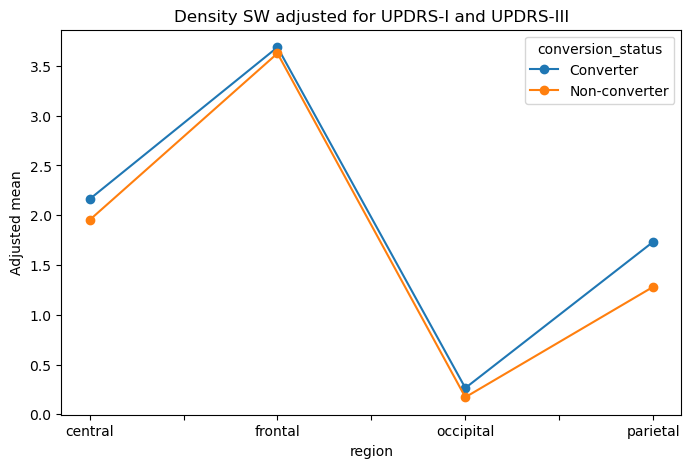

In [193]:
density = means[
    means["variable"] == "density_sw"
]

pivot_density = density.pivot(
    index="region",
    columns="conversion_status",
    values="adjusted_mean"
)

pivot_density.plot(
    marker="o",
    figsize=(8,5)
)

plt.ylabel("Adjusted mean")
plt.title("Density SW adjusted for UPDRS-I and UPDRS-III")
plt.show()

In [194]:
import pandas as pd

ancova = pd.read_csv(
    "../results/ancova/repeated_measures_ancova_all_effects.csv"
)

ancova.head()

,effect,sum_sq,df,F,PR(>F),variable
0,C(conversion_status),1.092981,1.0,0.510955,4.753673e-01,density_sw
1,C(region),535.859315,3.0,83.502460,7.312536e-38,density_sw
2,C(filename),2221.215980,89.0,11.667304,1.972388e-54,density_sw
3,C(conversion_status):C(region),2.018037,3.0,0.314469,8.149179e-01,density_sw
4,"Q(""UPDRS-I Total"")",0.530883,1.0,0.248181,6.187800e-01,density_sw


In [195]:
ancova.columns

Index(['effect', 'sum_sq', 'df', 'F', 'PR(>F)', 'variable'], dtype='object')

In [196]:
# on va vérifier es variables avec les effets les plus significatifs 
ancova.sort_values(
    "PR(>F)"
).head(30)

,effect,sum_sq,df,F,PR(>F),variable
72,C(filename),8.329571e+01,89.0,178.600531,2.126227e-190,total_freq_Hz
86,C(filename),8.797340e+01,89.0,154.459209,1.646346e-182,total_N2_freq_Hz
79,C(filename),6.315934e+05,89.0,149.280550,1.161844e-180,total_pkpk_amp_uV
135,C(filename),5.271018e+05,75.0,324.633823,1.914156e-176,total_N3_pkpk_amp_uV
51,C(filename),1.022131e+02,89.0,124.710863,6.102254e-171,total_trans_freq_Hz
128,C(filename),6.287825e+05,89.0,123.977639,1.268757e-170,total_N2_pkpk_amp_uV
100,C(filename),1.118463e+02,89.0,108.580997,1.722783e-163,total_N2_trans_freq_Hz
65,C(filename),7.312769e+06,89.0,93.336361,2.155572e-155,total_slope_0_min
44,C(filename),6.916486e+01,89.0,87.132005,9.983045e-152,total_sw_sec
93,C(filename),6.268258e+01,75.0,172.582444,1.989850e-149,total_N3_freq_Hz


In [210]:
#maintenant, on va se concentrer surtout sur les effet Groupe 
# pourvoir, en gros, est ce que les convertisseurs diffèrent des non convertisseurs pour nos variables d'ondes lentes 
group_effects = ancova[
    ancova["effect"] == "C(conversion_status)"
]

group_effects.sort_values(
    "PR(>F)"
)

,effect,sum_sq,df,F,PR(>F),variable
49,C(conversion_status),0.566721,1.0,61.540012,1.178927e-13,total_trans_freq_Hz
70,C(conversion_status),0.289700,1.0,55.283906,1.569863e-12,total_freq_Hz
105,C(conversion_status),0.435900,1.0,44.546807,2.389366e-10,total_N3_trans_freq_Hz
91,C(conversion_status),0.191580,1.0,39.560547,1.964092e-09,total_N3_freq_Hz
98,C(conversion_status),0.393239,1.0,33.976490,1.672601e-08,total_N2_trans_freq_Hz
84,C(conversion_status),0.209873,1.0,32.795083,2.862416e-08,total_N2_freq_Hz
56,C(conversion_status),22621.947011,1.0,31.798958,4.512262e-08,total_slope_min_max
63,C(conversion_status),15346.917563,1.0,17.433322,4.082499e-05,total_slope_0_min
112,C(conversion_status),14515.818514,1.0,14.001085,2.255666e-04,total_N2_slope_0_min
133,C(conversion_status),211.863138,1.0,9.786241,2.020753e-03,total_N3_pkpk_amp_uV


In [198]:
group_effects[
    group_effects["PR(>F)"] < 0.05
]

,effect,sum_sq,df,F,PR(>F),variable
14,C(conversion_status),400792.622861,1.0,8.714675,3.445014e-03,total_N3_sw_count
21,C(conversion_status),653749.668285,1.0,5.905269,1.577297e-02,total_sw_count
49,C(conversion_status),0.566721,1.0,61.540012,1.178927e-13,total_trans_freq_Hz
56,C(conversion_status),22621.947011,1.0,31.798958,4.512262e-08,total_slope_min_max
63,C(conversion_status),15346.917563,1.0,17.433322,4.082499e-05,total_slope_0_min
70,C(conversion_status),0.289700,1.0,55.283906,1.569863e-12,total_freq_Hz
77,C(conversion_status),370.342963,1.0,7.790400,5.648109e-03,total_pkpk_amp_uV
84,C(conversion_status),0.209873,1.0,32.795083,2.862416e-08,total_N2_freq_Hz
91,C(conversion_status),0.191580,1.0,39.560547,1.964092e-09,total_N3_freq_Hz
98,C(conversion_status),0.393239,1.0,33.976490,1.672601e-08,total_N2_trans_freq_Hz


In [199]:
# on va maintenant voir l'effet région 
region_effects = ancova[
    ancova["effect"] == "C(region)"
]

region_effects.sort_values(
    "PR(>F)"
)

,effect,sum_sq,df,F,PR(>F),variable
71,C(region),3.323578e+00,3.0,211.414510,5.648933e-69,total_freq_Hz
64,C(region),5.422960e+05,3.0,205.340264,7.940380e-68,total_slope_0_min
50,C(region),5.322369e+00,3.0,192.651165,2.382371e-65,total_trans_freq_Hz
85,C(region),3.477040e+00,3.0,181.109361,5.372731e-63,total_N2_freq_Hz
113,C(region),5.569944e+05,3.0,179.081076,1.426300e-62,total_N2_slope_0_min
99,C(region),5.933565e+00,3.0,170.890030,7.947196e-61,total_N2_trans_freq_Hz
57,C(region),3.558897e+05,3.0,166.754302,6.354012e-60,total_slope_min_max
43,C(region),4.233192e+00,3.0,158.208166,5.204947e-58,total_sw_sec
134,C(region),1.208942e+04,3.0,186.142172,1.258987e-57,total_N3_pkpk_amp_uV
29,C(region),4.191992e+00,3.0,142.626694,2.419832e-54,total_N2_sw_sec


In [200]:
# on vérifie les intéractions potentiels 
interaction_effects = ancova[
    ancova["effect"] == "C(conversion_status):C(region)"
]

interaction_effects.sort_values(
    "PR(>F)"
)

,effect,sum_sq,df,F,PR(>F),variable
52,C(conversion_status):C(region),0.161856,3.0,5.858633,0.000696,total_trans_freq_Hz
73,C(conversion_status):C(region),0.066166,3.0,4.208842,0.006279,total_freq_Hz
136,C(conversion_status):C(region),247.977630,3.0,3.818139,0.010861,total_N3_pkpk_amp_uV
45,C(conversion_status):C(region),0.083554,3.0,3.122689,0.026521,total_sw_sec
101,C(conversion_status):C(region),0.091865,3.0,2.645765,0.049616,total_N2_trans_freq_Hz
59,C(conversion_status):C(region),5397.043455,3.0,2.528818,0.057796,total_slope_min_max
17,C(conversion_status):C(region),337788.700826,3.0,2.448248,0.064148,total_N3_sw_count
87,C(conversion_status):C(region),0.044468,3.0,2.316190,0.076183,total_N2_freq_Hz
108,C(conversion_status):C(region),0.056386,3.0,1.920780,0.127428,total_N3_trans_freq_Hz
31,C(conversion_status):C(region),0.054668,3.0,1.860009,0.136806,total_N2_sw_sec


In [201]:
# on se fait un petit résumé rapide 
print(
    "Group:",
    (group_effects["PR(>F)"] < 0.05).sum()
)

print(
    "Region:",
    (region_effects["PR(>F)"] < 0.05).sum()
)

print(
    "Interaction:",
    (interaction_effects["PR(>F)"] < 0.05).sum()
)

Group: 14
Region: 20
Interaction: 5


In [209]:
# pour l'interprétation pour toutes les régions confondues 
group_effects = ancova[
    ancova["effect"] == "C(conversion_status)"
]

group_effects.sort_values(
    "PR(>F)"
)

,effect,sum_sq,df,F,PR(>F),variable
49,C(conversion_status),0.566721,1.0,61.540012,1.178927e-13,total_trans_freq_Hz
70,C(conversion_status),0.289700,1.0,55.283906,1.569863e-12,total_freq_Hz
105,C(conversion_status),0.435900,1.0,44.546807,2.389366e-10,total_N3_trans_freq_Hz
91,C(conversion_status),0.191580,1.0,39.560547,1.964092e-09,total_N3_freq_Hz
98,C(conversion_status),0.393239,1.0,33.976490,1.672601e-08,total_N2_trans_freq_Hz
84,C(conversion_status),0.209873,1.0,32.795083,2.862416e-08,total_N2_freq_Hz
56,C(conversion_status),22621.947011,1.0,31.798958,4.512262e-08,total_slope_min_max
63,C(conversion_status),15346.917563,1.0,17.433322,4.082499e-05,total_slope_0_min
112,C(conversion_status),14515.818514,1.0,14.001085,2.255666e-04,total_N2_slope_0_min
133,C(conversion_status),211.863138,1.0,9.786241,2.020753e-03,total_N3_pkpk_amp_uV


In [203]:
interaction_effects = ancova[
    ancova["effect"] == "C(conversion_status):C(region)"
]

interaction_effects.sort_values(
    "PR(>F)"
)

,effect,sum_sq,df,F,PR(>F),variable
52,C(conversion_status):C(region),0.161856,3.0,5.858633,0.000696,total_trans_freq_Hz
73,C(conversion_status):C(region),0.066166,3.0,4.208842,0.006279,total_freq_Hz
136,C(conversion_status):C(region),247.977630,3.0,3.818139,0.010861,total_N3_pkpk_amp_uV
45,C(conversion_status):C(region),0.083554,3.0,3.122689,0.026521,total_sw_sec
101,C(conversion_status):C(region),0.091865,3.0,2.645765,0.049616,total_N2_trans_freq_Hz
59,C(conversion_status):C(region),5397.043455,3.0,2.528818,0.057796,total_slope_min_max
17,C(conversion_status):C(region),337788.700826,3.0,2.448248,0.064148,total_N3_sw_count
87,C(conversion_status):C(region),0.044468,3.0,2.316190,0.076183,total_N2_freq_Hz
108,C(conversion_status):C(region),0.056386,3.0,1.920780,0.127428,total_N3_trans_freq_Hz
31,C(conversion_status):C(region),0.054668,3.0,1.860009,0.136806,total_N2_sw_sec


In [204]:
means = pd.read_csv(
    "../results/ancova/adjusted_means_by_group_and_region.csv"
)

means[
    means["variable"] == "density_sw"
]

,filename,conversion_status,region,UPDRS-I Total,UPDRS-III Total -0.5,adjusted_mean,variable
0,R108_2010,Converter,frontal,0.613764,3.859551,3.686970,density_sw
1,R108_2010,Converter,central,0.613764,3.859551,2.160807,density_sw
2,R108_2010,Converter,parietal,0.613764,3.859551,1.732879,density_sw
3,R108_2010,Converter,occipital,0.613764,3.859551,0.264324,density_sw
4,R108_2010,Non-converter,frontal,0.613764,3.859551,3.625635,density_sw
5,R108_2010,Non-converter,central,0.613764,3.859551,1.951257,density_sw
6,R108_2010,Non-converter,parietal,0.613764,3.859551,1.280670,density_sw
7,R108_2010,Non-converter,occipital,0.613764,3.859551,0.171686,density_sw


In [205]:
# ANCOVA Verification
# because somthing in the results seems wrong 

In [206]:
print(df.shape)

print(df["converter"].value_counts())

print(df["conversion_subtype"].value_counts())

(97, 116)
converter
0    60
1    37
Name: count, dtype: int64
conversion_subtype
Non-converter    60
DLB              20
PD                9
PD-MCI            8
Name: count, dtype: int64


In [207]:
#  les variables significatives semsblent redevenir normal après que les participants exclu (MSA) soient exclues 
group_effects = ancova[
    ancova["effect"] == "C(conversion_status)"
]

group_effects.sort_values("PR(>F)")

,effect,sum_sq,df,F,PR(>F),variable
49,C(conversion_status),0.566721,1.0,61.540012,1.178927e-13,total_trans_freq_Hz
70,C(conversion_status),0.289700,1.0,55.283906,1.569863e-12,total_freq_Hz
105,C(conversion_status),0.435900,1.0,44.546807,2.389366e-10,total_N3_trans_freq_Hz
91,C(conversion_status),0.191580,1.0,39.560547,1.964092e-09,total_N3_freq_Hz
98,C(conversion_status),0.393239,1.0,33.976490,1.672601e-08,total_N2_trans_freq_Hz
84,C(conversion_status),0.209873,1.0,32.795083,2.862416e-08,total_N2_freq_Hz
56,C(conversion_status),22621.947011,1.0,31.798958,4.512262e-08,total_slope_min_max
63,C(conversion_status),15346.917563,1.0,17.433322,4.082499e-05,total_slope_0_min
112,C(conversion_status),14515.818514,1.0,14.001085,2.255666e-04,total_N2_slope_0_min
133,C(conversion_status),211.863138,1.0,9.786241,2.020753e-03,total_N3_pkpk_amp_uV


In [208]:
# je revérifie qu'il s'agit du bon nbr de participants 
df = pd.read_csv("../data/processed/final_dataset.csv")

print(df.shape)

print(df["converter"].value_counts())

(97, 116)
converter
0    60
1    37
Name: count, dtype: int64


In [ ]:
# les data qui sont significativement différentes entre les deux groupes sont : 

### Variables significativement différentes entre convertisseurs et non-convertisseurs (p < 0.05)

##**Fréquence**

##* total_trans_freq_Hz
##* total_freq_Hz
##* total_N3_trans_freq_Hz
##* total_N3_freq_Hz
##* total_N2_trans_freq_Hz
##* total_N2_freq_Hz

##**Pente**

##* total_slope_min_max
##* total_slope_0_min
##* total_N2_slope_0_min

##**Amplitude**

##* total_pkpk_amp_uV
##* total_N2_pkpk_amp_uV
##* total_N3_pkpk_amp_uV

##**Nombre d'ondes lentes**

##* total_sw_count
##* total_N3_sw_count

##**Total : 14 variables significatives.**



In [ ]:
# ANCOVA Verification


#Goal:
#Verify the repeated-measures ANCOVA implementation before proceeding to machine learning analyses.

#Questions:
#- Which participants are included?
#- Which variables are significant?
#- Which model is being tested?
#- Is the repeated-measures structure correctly implemented?
#- Why do results differ from previous R analyses?


In [211]:
# je vais sauvegarder le data set utilisé 
import pandas as pd

df = pd.read_csv(
    "../data/processed/final_dataset.csv"
)

print(df.shape)

print(df["converter"].value_counts())

print(df["conversion_status"].value_counts())

(97, 116)
converter
0    60
1    37
Name: count, dtype: int64
conversion_status
Non-converter    60
Converter        37
Name: count, dtype: int64


In [212]:
# et ensuite je sauvegarde les résultats de l'ANCOVA
ancova = pd.read_csv(
    "../results/ancova/repeated_measures_ancova_all_effects.csv"
)

ancova.head()

,effect,sum_sq,df,F,PR(>F),variable
0,C(conversion_status),1.092981,1.0,0.510955,4.753673e-01,density_sw
1,C(region),535.859315,3.0,83.502460,7.312536e-38,density_sw
2,C(filename),2221.215980,89.0,11.667304,1.972388e-54,density_sw
3,C(conversion_status):C(region),2.018037,3.0,0.314469,8.149179e-01,density_sw
4,"Q(""UPDRS-I Total"")",0.530883,1.0,0.248181,6.187800e-01,density_sw


In [ ]:
## Significant group effects

#p < 0.05

##- total_freq_Hz
##- total_N3_trans_freq_Hz
##- total_N3_freq_Hz
##- total_N2_trans_freq_Hz
##- total_N2_freq_Hz
##- total_slope_min_max
##- total_slope_0_min
##- total_N2_slope_0_min
##- total_pkpk_amp_uV
##- total_N2_pkpk_amp_uV
##- total_N3_pkpk_amp_uV
##- total_sw_count
##- total_N3_sw_count

In [213]:
# on vérifie les interactions 
interaction_effects = ancova[
    ancova["effect"] == "C(conversion_status):C(region)"
]

interaction_effects.sort_values(
    "PR(>F)"
)

,effect,sum_sq,df,F,PR(>F),variable
52,C(conversion_status):C(region),0.161856,3.0,5.858633,0.000696,total_trans_freq_Hz
73,C(conversion_status):C(region),0.066166,3.0,4.208842,0.006279,total_freq_Hz
136,C(conversion_status):C(region),247.977630,3.0,3.818139,0.010861,total_N3_pkpk_amp_uV
45,C(conversion_status):C(region),0.083554,3.0,3.122689,0.026521,total_sw_sec
101,C(conversion_status):C(region),0.091865,3.0,2.645765,0.049616,total_N2_trans_freq_Hz
59,C(conversion_status):C(region),5397.043455,3.0,2.528818,0.057796,total_slope_min_max
17,C(conversion_status):C(region),337788.700826,3.0,2.448248,0.064148,total_N3_sw_count
87,C(conversion_status):C(region),0.044468,3.0,2.316190,0.076183,total_N2_freq_Hz
108,C(conversion_status):C(region),0.056386,3.0,1.920780,0.127428,total_N3_trans_freq_Hz
31,C(conversion_status):C(region),0.054668,3.0,1.860009,0.136806,total_N2_sw_sec


In [214]:
# modèle formula 
    
   # formula = (
     #   'value ~ C(conversion_status) * C(region) '
     #   '+ Q("UPDRS-I Total") '
     #   '+ Q("UPDRS-III Total -0.5") '
     #   '+ C(filename)'
    #)



In [215]:
# on vérifie le dat set utilisé 
import pandas as pd

df = pd.read_csv(
    "../data/processed/final_dataset.csv"
)

print("Shape:")
print(df.shape)

print("\nConverter counts:")
print(df["converter"].value_counts())

print("\nConversion status:")
print(df["conversion_status"].value_counts())

Shape:
(97, 116)

Converter counts:
converter
0    60
1    37
Name: count, dtype: int64

Conversion status:
conversion_status
Non-converter    60
Converter        37
Name: count, dtype: int64


In [216]:
# on vérifie les varibales présentes 
print(df.columns.tolist())

['filename', 'central_recording_min', 'frontal_recording_min', 'occipital_recording_min', 'parietal_recording_min', 'central_sleep_period_min', 'frontal_sleep_period_min', 'occipital_sleep_period_min', 'parietal_sleep_period_min', 'central_total_N2_valid_min', 'frontal_total_N2_valid_min', 'occipital_total_N2_valid_min', 'parietal_total_N2_valid_min', 'central_total_N3_valid_min', 'frontal_total_N3_valid_min', 'occipital_total_N3_valid_min', 'parietal_total_N3_valid_min', 'central_total_valid_min', 'frontal_total_valid_min', 'occipital_total_valid_min', 'parietal_total_valid_min', 'central_total_N2_sw_count', 'frontal_total_N2_sw_count', 'occipital_total_N2_sw_count', 'parietal_total_N2_sw_count', 'central_total_N3_sw_count', 'frontal_total_N3_sw_count', 'occipital_total_N3_sw_count', 'parietal_total_N3_sw_count', 'central_total_sw_count', 'frontal_total_sw_count', 'occipital_total_sw_count', 'parietal_total_sw_count', 'central_total_N2_sw_sec', 'frontal_total_N2_sw_sec', 'occipital_to

In [217]:
# on charge les résultats de l'ANCOVA 
ancova = pd.read_csv(
    "../results/ancova/repeated_measures_ancova_all_effects.csv"
)

ancova.head()

,effect,sum_sq,df,F,PR(>F),variable
0,C(conversion_status),1.092981,1.0,0.510955,4.753673e-01,density_sw
1,C(region),535.859315,3.0,83.502460,7.312536e-38,density_sw
2,C(filename),2221.215980,89.0,11.667304,1.972388e-54,density_sw
3,C(conversion_status):C(region),2.018037,3.0,0.314469,8.149179e-01,density_sw
4,"Q(""UPDRS-I Total"")",0.530883,1.0,0.248181,6.187800e-01,density_sw


In [218]:
ancova.shape

(140, 6)

In [219]:
# on extratit l'effet de groupes 
group_effects = ancova[
    ancova["effect"] == "C(conversion_status)"
]

group_effects.sort_values(
    "PR(>F)"
)

,effect,sum_sq,df,F,PR(>F),variable
49,C(conversion_status),0.566721,1.0,61.540012,1.178927e-13,total_trans_freq_Hz
70,C(conversion_status),0.289700,1.0,55.283906,1.569863e-12,total_freq_Hz
105,C(conversion_status),0.435900,1.0,44.546807,2.389366e-10,total_N3_trans_freq_Hz
91,C(conversion_status),0.191580,1.0,39.560547,1.964092e-09,total_N3_freq_Hz
98,C(conversion_status),0.393239,1.0,33.976490,1.672601e-08,total_N2_trans_freq_Hz
84,C(conversion_status),0.209873,1.0,32.795083,2.862416e-08,total_N2_freq_Hz
56,C(conversion_status),22621.947011,1.0,31.798958,4.512262e-08,total_slope_min_max
63,C(conversion_status),15346.917563,1.0,17.433322,4.082499e-05,total_slope_0_min
112,C(conversion_status),14515.818514,1.0,14.001085,2.255666e-04,total_N2_slope_0_min
133,C(conversion_status),211.863138,1.0,9.786241,2.020753e-03,total_N3_pkpk_amp_uV


In [220]:
# vérification ineraction région x groupes 
interaction_effects = ancova[
    ancova["effect"] == "C(conversion_status):C(region)"
]

interaction_effects.sort_values(
    "PR(>F)"
)

,effect,sum_sq,df,F,PR(>F),variable
52,C(conversion_status):C(region),0.161856,3.0,5.858633,0.000696,total_trans_freq_Hz
73,C(conversion_status):C(region),0.066166,3.0,4.208842,0.006279,total_freq_Hz
136,C(conversion_status):C(region),247.977630,3.0,3.818139,0.010861,total_N3_pkpk_amp_uV
45,C(conversion_status):C(region),0.083554,3.0,3.122689,0.026521,total_sw_sec
101,C(conversion_status):C(region),0.091865,3.0,2.645765,0.049616,total_N2_trans_freq_Hz
59,C(conversion_status):C(region),5397.043455,3.0,2.528818,0.057796,total_slope_min_max
17,C(conversion_status):C(region),337788.700826,3.0,2.448248,0.064148,total_N3_sw_count
87,C(conversion_status):C(region),0.044468,3.0,2.316190,0.076183,total_N2_freq_Hz
108,C(conversion_status):C(region),0.056386,3.0,1.920780,0.127428,total_N3_trans_freq_Hz
31,C(conversion_status):C(region),0.054668,3.0,1.860009,0.136806,total_N2_sw_sec


In [221]:
df.columns.tolist()

['filename',
 'central_recording_min',
 'frontal_recording_min',
 'occipital_recording_min',
 'parietal_recording_min',
 'central_sleep_period_min',
 'frontal_sleep_period_min',
 'occipital_sleep_period_min',
 'parietal_sleep_period_min',
 'central_total_N2_valid_min',
 'frontal_total_N2_valid_min',
 'occipital_total_N2_valid_min',
 'parietal_total_N2_valid_min',
 'central_total_N3_valid_min',
 'frontal_total_N3_valid_min',
 'occipital_total_N3_valid_min',
 'parietal_total_N3_valid_min',
 'central_total_valid_min',
 'frontal_total_valid_min',
 'occipital_total_valid_min',
 'parietal_total_valid_min',
 'central_total_N2_sw_count',
 'frontal_total_N2_sw_count',
 'occipital_total_N2_sw_count',
 'parietal_total_N2_sw_count',
 'central_total_N3_sw_count',
 'frontal_total_N3_sw_count',
 'occipital_total_N3_sw_count',
 'parietal_total_N3_sw_count',
 'central_total_sw_count',
 'frontal_total_sw_count',
 'occipital_total_sw_count',
 'parietal_total_sw_count',
 'central_total_N2_sw_sec',
 'front

In [222]:
df.columns.tolist()

['filename',
 'central_recording_min',
 'frontal_recording_min',
 'occipital_recording_min',
 'parietal_recording_min',
 'central_sleep_period_min',
 'frontal_sleep_period_min',
 'occipital_sleep_period_min',
 'parietal_sleep_period_min',
 'central_total_N2_valid_min',
 'frontal_total_N2_valid_min',
 'occipital_total_N2_valid_min',
 'parietal_total_N2_valid_min',
 'central_total_N3_valid_min',
 'frontal_total_N3_valid_min',
 'occipital_total_N3_valid_min',
 'parietal_total_N3_valid_min',
 'central_total_valid_min',
 'frontal_total_valid_min',
 'occipital_total_valid_min',
 'parietal_total_valid_min',
 'central_total_N2_sw_count',
 'frontal_total_N2_sw_count',
 'occipital_total_N2_sw_count',
 'parietal_total_N2_sw_count',
 'central_total_N3_sw_count',
 'frontal_total_N3_sw_count',
 'occipital_total_N3_sw_count',
 'parietal_total_N3_sw_count',
 'central_total_sw_count',
 'frontal_total_sw_count',
 'occipital_total_sw_count',
 'parietal_total_sw_count',
 'central_total_N2_sw_sec',
 'front